# Student Success and Wellbeing Index

- **Module:** Data Analysis and Visualization
- **Assessment:** CA1 - Composite Indicator
- **Student Name:** Liam Moore
- **Student Number:** D00254813

## Introduction

- The aim of my project is to create a composite indicator called the **Student Sucess and Wellbeing Index**. The purpose of this index is to combine different aspects of student life into a single score.

- The dataset I selected includes variables such as:
    - **Study_Hours_Per_Day**, 
    - **Extracurricular_Hours_Per_Day**, 
    - **Sleep_Hours_Per_Day**, 
    - **Social_Hours_Per_Day**, 
    - **Physical_Activity_Hours_Per_Day**, 
    - **GPA**
    - **Stress_Level** 
- I choose these as they all play a role in a students overall performance and wellbeing.

- I will clean the data, normalise it, and group it into smaller sub indicies before combining them into a final score. I will also preform basic analysis to understand the relationship between the variables.

- The index will allow students to be compared and will help show how different lifestyle factors can affect a students academic success and overall wellbeing.

# Theoretical Framework

- A composite indicator is a single score created by combining multiple variables. It is useful whhen trying to measure something complex that cannot be represented by one value.

- For this project, the Student Success and Wellbeiing Indeex is made up of three main components:
    - **Academic Performance**
        - GPA 
        - Study_Hours_Per_Day
    - **Wellbeing** 
        - Sleep_Hours_Per_Day
        - Stress_Level
    - **Lifestyle** 
        - Social_Hours_Per_Day 
        - Physical_Activity_Hours_Per_Day 
        - Extracurricular_Hours_Per_Day

- The reason that I chose the variables is because they are important factors that heavily influence how well a student performs. For example, good sleep and low stress can improve a students focus , while physical activity and social activities contribute to a students overall wellbeing.

- By combining these factors into a single index, it is possible to compare student and better understand what leads to success.

## Data Selection

- For the projeect, I selected a student lifestyle dataset froom kaggle containing around 2000 rows of data. Each row represents a student and includes information about their daily activities and academic performance. 

- The dataset includes variables such as **study hours**, **sleep hours**, **social activity**, **physical activity**, **extracurricular activity**, **GPA**, and **stress level**.

- I chose the dataset because It included a good mix of academic and lifestyle factors, which are both important  when measuring student success and wellbeing. Most of the variables are numerical, making them suitable for analysis, normalisation, and building a composite index.

- The size of the dataset also makes it useful for identifying patterns and carrying out further analysis such as clustering and visualisation.

# Handling Missing Data & Cleaning

In [125]:
import pandas as pd

df = pd.read_csv('student_lifestyle_dataset.csv')

df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [126]:
df = df.drop(columns=['Student_ID'], axis=1)

In [127]:
df.isnull().sum()

Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64

- I checked the dataset for missing values using the **isnull()** function.

- I then removed the Student_ID column as it had no purpose.

- The result shows that there is no missing values in any of the variables within the dataset, meaning it's complete. Because of this I did'nt have to remove any data.


- If there had of been missing values within the dataset I would of handled it by estimating them using the mean of the variable.

In [128]:
stress = {
    "Low": 1,
    "Moderate": 2,
    "High": 3
}

df['Stress_Level'] = df['Stress_Level'].map(stress)

df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,2
1,5.3,3.5,8.0,4.2,3.0,2.75,1
2,5.1,3.9,9.2,1.2,4.6,2.67,1
3,6.5,2.1,7.2,1.7,6.5,2.88,2
4,8.1,0.6,6.5,2.2,6.6,3.51,3


- I noticed in the dataset that the Stress_Level variable was originally categorical, the values were:
    - **Low**
    - **Moderate**
    - **High**

- I converted the variable into numerical values (1, 2, 3) so that it can be used in calculations and included in the index.

## Normalisation

- The variables in the dataset are measure on different scales. For example, GPA is measured on a smaller scale compared to variables such as study hours or sleep hours.

- Because of this, I need to normalise the data so that all variables can be compared fairly. If normalisation was conducted, variables with larger values **(e.g. Sleep_Hours)** could have a bigger influence on the final index.

- For my dataset, I used Min-Max normalisation which I used in previous modules(AI, Data Science)to scale all of the variables between 0 and 1.

In [129]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "GPA",
    "Stress_Level"
]

df[cols] = scaler.fit_transform(df[cols])

df["Stress_Level"] = 1 - df["Stress_Level"]

df.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,0.38,0.950,0.74,0.466667,0.138462,0.426136,0.5
1,0.06,0.875,0.60,0.700000,0.230769,0.289773,1.0
2,0.02,0.975,0.84,0.200000,0.353846,0.244318,1.0
3,0.30,0.525,0.44,0.283333,0.500000,0.363636,0.5
4,0.62,0.150,0.30,0.366667,0.507692,0.721591,0.0


## Multivariate Analysis
# Correlation

- In this section, I look at the relationships between the different variables in the dataset.

- I feel like this is extremely important because it helps me understand how different factors are connected and which ones may have a greater influence on student success and wellbeing.

- Within this section I will conduct correlation analysis, look at multicollinearity, and apply clustering to explore patterns in the data.

In [130]:
corr = df.corr()
corr

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
Study_Hours_Per_Day,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468,-0.738843
Extracurricular_Hours_Per_Day,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174,0.006099
Sleep_Hours_Per_Day,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278,0.298917
Social_Hours_Per_Day,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677,0.054702
Physical_Activity_Hours_Per_Day,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152,0.205207
GPA,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000,-0.550395
Stress_Level,-0.738843,0.006099,0.298917,0.054702,0.205207,-0.550395,1.000000


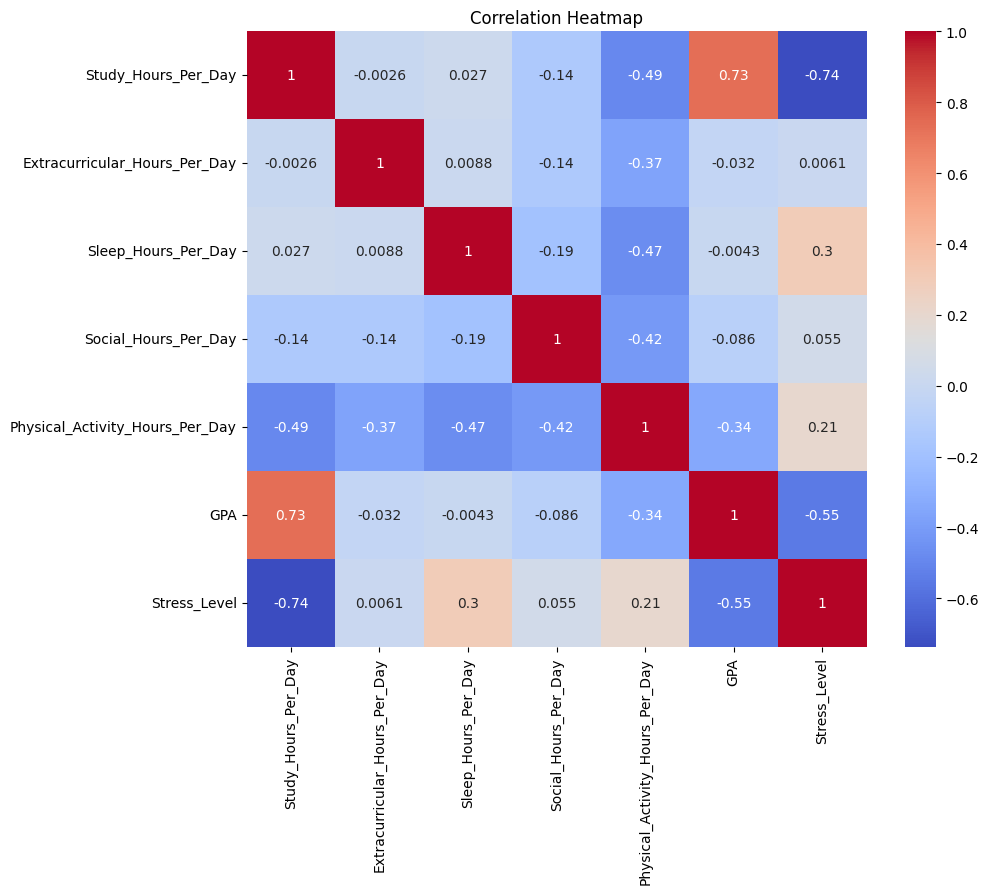

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [132]:
corr["GPA"].sort_values(ascending=False)

GPA                                1.000000
Study_Hours_Per_Day                0.734468
Sleep_Hours_Per_Day               -0.004278
Extracurricular_Hours_Per_Day     -0.032174
Social_Hours_Per_Day              -0.085677
Physical_Activity_Hours_Per_Day   -0.341152
Stress_Level                      -0.550395
Name: GPA, dtype: float64

In [133]:
corr["Stress_Level"].sort_values(ascending=True)

Study_Hours_Per_Day               -0.738843
GPA                               -0.550395
Extracurricular_Hours_Per_Day      0.006099
Social_Hours_Per_Day               0.054702
Physical_Activity_Hours_Per_Day    0.205207
Sleep_Hours_Per_Day                0.298917
Stress_Level                       1.000000
Name: Stress_Level, dtype: float64

- From the correlation matrix and heatmap above, we cam see the relationships between the variables in the dataset.

- I can see from the data that most of the relationships between variables are quite weak, as the majority of the values are close to 0. This means that most of the variables do not have a strong linear relationships with each other.

- One of the stronger relationships that I can see from the data is between GPA and study hours, which shows a strong posotive correlation (0.73). This suggests that students who study more temd to have a higher GPA. 

- I also noticed some strong negative relationships stress levels and study hours (-0.74). Which suggests that as stress increases, study hours decrease, while students who study more tend to have lower stress levels.

- Overall, the results shows that while most of the variables are not strongly related, a few key relationships stand out and help explain patterns in student behaviour.


# Clustering

In [134]:
X = df[cols]


In [135]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [136]:
k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X)
    sse.append(km.inertia_)

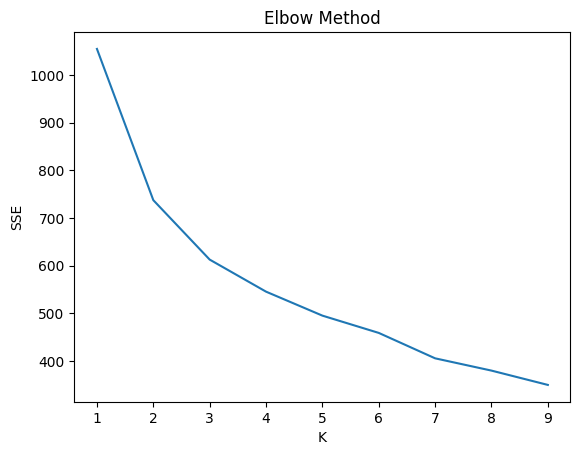

In [137]:
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.plot(k_range, sse)
plt.show()

- I used the elbow method to see thhe number of clusters to use in my analysis.

- From the graph, I can see a sharp decrease in SSE from k = 1 to k = 3. After this k = 3, the decrease becoomes more gradual, which suggests that adding more clusters does not significantly improve thhe model.

- Based on this, I selected k = 3 as the optimal number of clusters.

In [138]:
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster'] = km.fit_predict(X)
df.groupby('Cluster').mean()   

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
Cluster,,,,,,,
0,0.521545,0.474187,0.131138,0.559688,0.421670,0.508280,0.008130
1,0.300415,0.501661,0.599751,0.462132,0.363056,0.408908,0.654206
2,0.815450,0.511284,0.657651,0.332324,0.199647,0.645058,0.000000


- To better understand the clusters, I analysed the average values within each group.

- **Cluster 0:** Seems to represent balanced students, with reasonable study hours, average GPA, and very low stress levels. These students also seem to have a relatively high social activity.

- **Cluster 1:** represents students with higher stress levels and lower academic performance (Study hours, GPA). This suggests that stress may be a cause for affecting their performance.

- **Cluster 2:** represents high achieving students, with high study hours GPAs. These students also seem to have very low stress levels, but lower social activity, which could mean that they are more focused on academics.

- Overall, the results show that the students with different lifestyle and study habits tend to have different levels of academic performance and wellbeing.

# Multiple Linear Regression

In [139]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
X = df[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Stress_Level', 'Physical_Activity_Hours_Per_Day']]
y = df['GPA']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     470.0
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:20:12   Log-Likelihood:                 1488.7
No. Observations:                2000   AIC:                            -2965.
Df Residuals:                    1994   BIC:                            -2932.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

- Here I carried out multiple linear regression to eexamin how different lifestyle factors related to GPA

- The model shows that approximately 54% of the variation in GPA can be explained by the variables that I included in the analysis.

- Study hours have the strongest posotive relationship with GPA (0.46), which suggests that students who study more tend to have a higher grades.

- Physical activity (0.056) and social hours (0.030) shows smaller posotive realtionships with GPA, which suggests that they may have a slight posotive impact. 

- Other variables such as sleep, extracurricular activity, and stress do not seem to show a strong relationship with GPA in this model.

- From the model above, the results support my earlier analysis, showing that study habits are one of the most important factors influencing a students GPA.

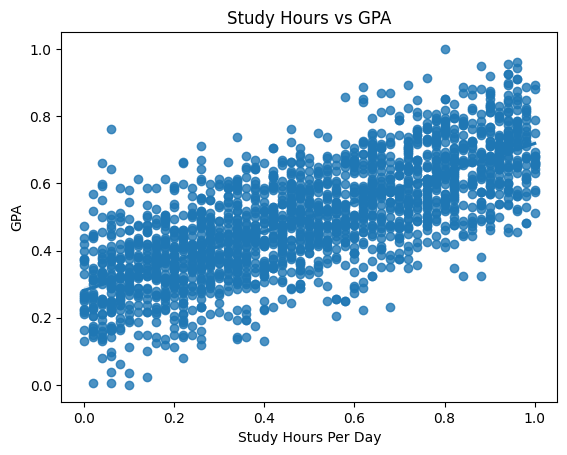

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='Study_Hours_Per_Day', y='GPA', data=df)
plt.title('Study Hours vs GPA')
plt.xlabel('Study Hours Per Day')
plt.ylabel('GPA')
plt.show()

- The regression plot shows a clear positive relationship between study hours and GPA. As study hours increase, GPA also tends to increase.

- This supports the regression results up above, where study hours had th strongest positive coefficent (0.46), indicating that its one of the most important factors influencing GPA.